## simplified anoGAN

Current state (what is working and what is not):
 - works fine in this implementation:
    Gen 
        - 3 conv layer
        - 5 fc layers
    Critic
        - 4 conv layers
        - 3 fc layers
    Encoder
        - 4 conv layers

works fine, is able to detect noisy points and also asigns high score to noise

ikdyz vse funguje jak ma encoder ma z nejakeho duvodu jen jednu naucenou reprezentaci

## Depencencies

In [116]:
import numpy as np
import matplotlib.pyplot as plt

In [117]:
import torch
import torch.nn as nn
import torch.nn.functional as F

## DATA

In [118]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.plotting_styles import apply_global_style
from anomaly_detection.utils.autoencoders import minmax_scale_per_sample
from anomaly_detection.utils.autoencoders import drop_empty_histograms

data_dir = "FJ"
dataset = load_dataset(data_dir)
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [120]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

# Models and testing

In [121]:
pt = torch.zeros(20).reshape(1,1,20)
generator = nn.Sequential(
                nn.ConvTranspose1d(in_channels=1, out_channels=4, kernel_size=4, stride=1),
                nn.ReLU(),
                nn.ConvTranspose1d(in_channels=4, out_channels=16, kernel_size=4, stride=2),
                nn.ReLU(),
                nn.ConvTranspose1d(in_channels=16, out_channels=16, kernel_size=4, stride=3))
torch.flatten(generator(pt)).shape

torch.Size([2320])

In [520]:
conv1 = nn.Conv1d(1, 32, 6, stride=2, padding=2)
conv2 = nn.Conv1d(32, 64, 4, stride=2, padding=2)
conv3 = nn.Conv1d(64, 128, 4, stride=2, padding=1)
conv4 = nn.Conv1d(128, 256, 4, stride=2, padding=1)
conv4(conv3(conv2(conv1(pt)))).shape

torch.Size([1, 256, 6])

In [457]:
conv4 = nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=4, stride=2, padding=1)
bn4 = nn.BatchNorm1d(1)
np.max(bn4(conv4(pt)).squeeze().detach().numpy())
bn4(conv4(pt))

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0.]]],
       grad_fn=<NativeBatchNormBackward0>)

In [521]:
class Generator(nn.Module):
    """Generates new data from the latent space"""
    def __init__(self):
        super(Generator, self).__init__()

        self.conv1 = nn.ConvTranspose1d(in_channels=32, out_channels=16, kernel_size=2, stride=2)
        self.bn1 = nn.BatchNorm1d(16)
        
        self.conv2 = nn.ConvTranspose1d(in_channels=16, out_channels=8, kernel_size=2, stride=2, padding=1)
        self.bn2 = nn.BatchNorm1d(8)
        
        self.conv3 = nn.ConvTranspose1d(in_channels=8, out_channels=4, kernel_size=4, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(4)
        
        self.conv4 = nn.ConvTranspose1d(in_channels=4, out_channels=1, kernel_size=4, stride=1, padding=1)
        #self.bn4 = nn.BatchNorm1d(1)
        
        #self.conv_smoother = nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=13, stride=1, padding=6)
    
    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(self.bn1(x))

        x = self.conv2(x)
        x = F.relu(self.bn2(x))

        x = self.conv3(x)
        x = F.relu(self.bn3(x))
        
        x = self.conv4(x)
        
        #x = self.conv_smoother(x)
        x = F.sigmoid(x)
        return x

class Discriminator(nn.Module):
    def __init__(self, latent_dim=6):
        super(Discriminator, self).__init__() 
        self.conv1 = nn.Conv1d(1, 32, 6, stride=2, padding=2)
        self.conv2 = nn.Conv1d(32, 64, 4, stride=2, padding=2)
        self.conv3 = nn.Conv1d(64, 128, 4, stride=2, padding=1)
        self.conv4 = nn.Conv1d(128, 256, 4, stride=2, padding=1)
        
        self.fc = nn.Sequential(
            nn.Linear(256 * latent_dim, 256),
            nn.Linear(256, 64),
            nn.LeakyReLU(0.2), 
            nn.Linear(64, 1)
        )

    def forward(self, x, return_features=False):
        f1 = F.leaky_relu(self.conv1(x), 0.2)
        f2 = F.leaky_relu(self.conv2(f1), 0.2)
        f3 = F.leaky_relu(self.conv3(f2), 0.2)
        f4 = F.leaky_relu(self.conv4(f3), 0.2)

        flat_features = torch.flatten(f4, 1)
        out = self.fc(flat_features)
        
        if return_features:
            # try returning f2 or f3
            return out, flat_features 
        return out

class Encoder(nn.Module):
    """Maps real data into latent space"""
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm1d(4)
        self.conv2 = nn.Conv1d(in_channels=4, out_channels=8, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm1d(8)
        self.conv3 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=2, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(16)
        self.conv4 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=2, stride=1)
        self.bn4 = nn.BatchNorm1d(32)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(self.bn1(x))

        x = self.conv2(x)
        x = F.relu(self.bn2(x))

        x = self.conv3(x)
        x = F.relu(self.bn3(x))
        
        x = self.conv4(x)
        return x

In [419]:
from torch.utils.data import DataLoader
from anomaly_detection.utils.autoencoders import HistDataset

## Training params

In [555]:
batch_size = 32

train_set = HistDataset(X_train)
test_set = HistDataset(X_test)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=True)

gen = Generator()
critic = Discriminator()
encoder = Encoder()

latent_dim = 24
latent_dim_n_filters = 32

lr = 5e-5
batch_size = 32
num_epochs_gan = 250 
num_epochs_enc = 250
critic_iterations = 6
lambda_gp = 10.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

optimizer_G = torch.optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.9))
optimizer_C = torch.optim.Adam(critic.parameters(), lr=lr, betas=(0.5, 0.9))
optimizer_E = torch.optim.Adam(encoder.parameters(), lr=lr)

In [518]:
def gradient_penalty(critic, real, fake):
    batch_size = real.size(0)

    eps = torch.rand(batch_size, 1, 1, device=real.device)

    # (B,1,1) to (B,1,96)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)

    d_hat = critic(x_hat)

    gradients = torch.autograd.grad(
        outputs=d_hat,
        inputs=x_hat,
        grad_outputs=torch.ones_like(d_hat),
        create_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gp


## Training

In [557]:
from anomaly_detection.config.paths import CHECKPOINT_DIR
import os
import time 
from pathlib import Path

gen.train()
critic.train()

critic_losses = []
gen_losses = []

val_losses_C = []
val_losses_G = []

folder_name_for_checkpoints = Path(f"f_ano_gan_train_date={time.strftime("%d-%m_%H-%M")}")
os.makedirs(os.path.join(CHECKPOINT_DIR, folder_name_for_checkpoints), exist_ok=True)

best_gap = 0.0

for epoch in range(num_epochs_gan):
    epoch_loss_C = 0.0
    epoch_loss_G = 0.0

    for real_data in train_loader:
        real_data = real_data.to(device)
        batch_size_gan_training = real_data.shape[0]
        
        # critic loop
        for _ in range(critic_iterations):
            gen.train()
            critic.train()

            z = torch.randn(batch_size_gan_training, latent_dim_n_filters, latent_dim, device=device)
            fake_data = gen(z).detach()
        
            fake_data = fake_data.reshape(batch_size_gan_training, 1, 96)
            real_data = real_data.reshape(batch_size_gan_training, 1, 96)

            loss_C = (
                critic(fake_data).mean() - critic(real_data).mean()
            )

            gp = gradient_penalty(critic, real_data, fake_data)
            loss_C_total = loss_C + lambda_gp * gp
            # loss to log
            epoch_loss_C += loss_C_total.item()  
            
            optimizer_C.zero_grad()
            loss_C_total.backward()
            optimizer_C.step()

        # generator part
        z = torch.randn(batch_size_gan_training, latent_dim_n_filters, latent_dim, device=device)
        fake_data = gen(z)
        fake_data = fake_data.reshape(batch_size_gan_training, 1, 96)
        
        loss_G = -critic(fake_data).mean()
        epoch_loss_G += loss_G.item()

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()
    
    gen.eval()
    critic.eval()
    with torch.no_grad():
        val_loss_C = 0.0
        val_loss_G = 0.0
        val_gap = 0.0
        
        for x in test_loader:
            
            batch_size_gan_validation = x.shape[0]
            z = torch.randn(batch_size_gan_validation, latent_dim_n_filters, latent_dim, device=device)

            fake_data = gen(z).detach().reshape(batch_size_gan_validation, 1, 96)
            real_data = x.reshape(x.shape[0], 1, 96)
            
            critic_fake_data = critic(fake_data).mean()
            critic_real_data = critic(real_data).mean()
            
            val_loss_C += (
                critic_fake_data - critic_real_data
            )
            
            val_loss_G += -critic_fake_data

            D_fake = critic_fake_data.item()
            D_real = critic_real_data.item()
            gap = D_real - D_fake
            
            val_gap += gap
        
        val_gap /= len(test_loader)

        if val_gap > best_gap:
            best_gap = val_gap
            #folder_name_for_checkpoints = Path(f"f_ano_gan_train_date={time.strftime("%d-%m_%H-%M")}")
            torch.save({
                "generator": gen.state_dict(),
                "discriminator": critic.state_dict(),
            }, os.path.join(CHECKPOINT_DIR, folder_name_for_checkpoints, f"gan_ep{epoch}.pth"))
            print(f"Saved checkpoint in epoch {epoch}")

        val_loss_G /= len(test_loader)
        val_loss_C /= len(test_loader)
        
        val_losses_G.append(val_loss_G)
        val_losses_C.append(val_loss_C)

    
    critic_losses.append(epoch_loss_C/(critic_iterations*len(train_loader)))
    gen_losses.append(epoch_loss_G/len(train_loader))

    if epoch % 20 == 0:
        print(f"Train Epoch loss: {epoch}/{num_epochs_gan} |", f"Critic: {val_loss_C.item():.4f} | Gen: {loss_G.item():.4f} ")
        print(f"    Test Epoch loss: {epoch}/{num_epochs_gan} |", f"Critic: {loss_C.item():.4f} | Gen: {val_loss_G.item():.4f} ")


Saved checkpoint in epoch 0
Train Epoch loss: 0/250 | Critic: -3.7442 | Gen: 3.2248 
    Test Epoch loss: 0/250 | Critic: -3.8327 | Gen: 3.3006 
Saved checkpoint in epoch 1
Saved checkpoint in epoch 3
Saved checkpoint in epoch 4
Saved checkpoint in epoch 5
Saved checkpoint in epoch 6
Saved checkpoint in epoch 13
Train Epoch loss: 20/250 | Critic: -4.1502 | Gen: 7.0969 
    Test Epoch loss: 20/250 | Critic: -4.1443 | Gen: 7.1257 
Train Epoch loss: 40/250 | Critic: -3.9790 | Gen: 7.5951 
    Test Epoch loss: 40/250 | Critic: -3.9743 | Gen: 7.5046 
Train Epoch loss: 60/250 | Critic: -3.7232 | Gen: 5.5794 
    Test Epoch loss: 60/250 | Critic: -3.7481 | Gen: 5.5628 
Train Epoch loss: 80/250 | Critic: -3.5265 | Gen: 4.1479 
    Test Epoch loss: 80/250 | Critic: -3.4365 | Gen: 4.1766 
Train Epoch loss: 100/250 | Critic: -3.4070 | Gen: 3.2219 
    Test Epoch loss: 100/250 | Critic: -3.3596 | Gen: 3.1807 
Train Epoch loss: 120/250 | Critic: -3.2797 | Gen: 2.5434 
    Test Epoch loss: 120/250 |

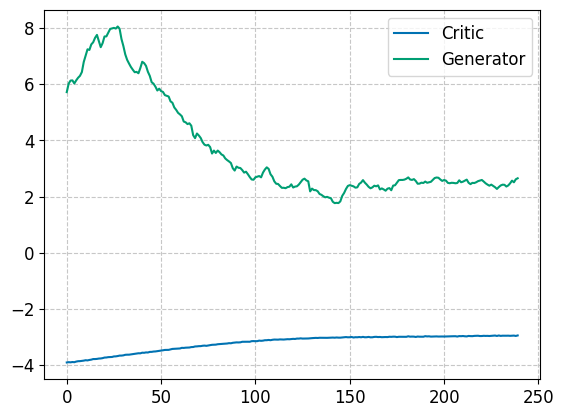

In [558]:
from anomaly_detection.utils.plotting_styles import apply_global_style 
apply_global_style()
plt.plot(range(len(critic_losses[10:])), critic_losses[10:], label='Critic')
plt.plot(range(len(gen_losses[10:])), gen_losses[10:], label='Generator')
plt.legend()
plt.show()

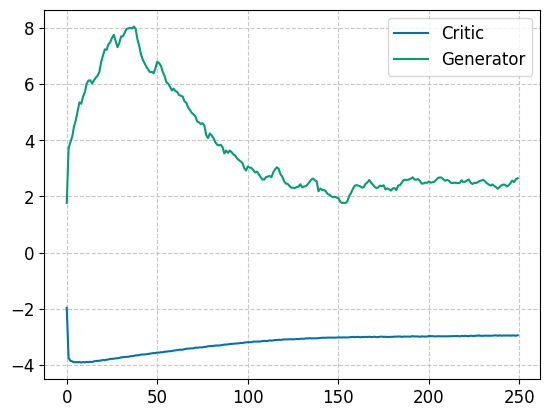

In [559]:
from anomaly_detection.utils.plotting_styles import apply_global_style 
apply_global_style()
plt.plot(range(len(critic_losses)), critic_losses, label='Critic')
plt.plot(range(len(gen_losses)), gen_losses, label='Generator')
plt.legend()
plt.show()

In [560]:
for p in gen.parameters():
    p.requires_grad = False

for p in critic.parameters():
    p.requires_grad = False

In [561]:
batch_size = 32

In [562]:
alpha = 0.9
beta = 0.1

train_losses = []
val_losses = []

encoder.train()

for epoch in range(num_epochs_enc):
    
    train_E_loss = []
    
    for x in train_loader:
        encoder.train()
        batch_size_encoder_training = x.shape[0]
        
        x = x.to(device)
        x = x.reshape(batch_size_encoder_training, 1, x.shape[-1])

        z = encoder(x)
        x_hat = gen(z)

        # reconstruction loss
        loss_rec = torch.mean(torch.abs(x - x_hat))

        # feature matching
        _, feat_x = critic(x, return_features=True)
        x_hat = x_hat.reshape(batch_size_encoder_training, 1, x.shape[-1])
        _, feat_x_hat = critic(x_hat, return_features=True)

        loss_feat = torch.mean(torch.abs(feat_x - feat_x_hat))

        loss_E = alpha * loss_rec + beta * loss_feat
        
        optimizer_E.zero_grad()
        loss_E.backward()
        optimizer_E.step()
    
    #train_losses.append(train_E_loss/len(train_loader))
    encoder.eval()

    with torch.no_grad():
        valiadtion_E_loss = 0.0
        for x in test_loader:
            batch_size_encoder_validation = x.shape[0]

            z = encoder(x)
            x_hat = gen(z)

            # reconstruction loss
            loss_rec_val = torch.mean(torch.abs(x - x_hat))

            # feature matching
            _, feat_x = critic(x, return_features=True)
            x_hat = x_hat.reshape(x_hat.shape[0], 1, x.shape[-1])
            _, feat_x_hat = critic(x_hat, return_features=True)

            loss_feat_val = torch.mean(torch.abs(feat_x - feat_x_hat))

            loss_E_val = alpha * loss_rec_val + beta * loss_feat_val
            valiadtion_E_loss += loss_E_val.item()

        val_losses.append(valiadtion_E_loss/len(test_loader))
    
    
    encoder.eval() 
    if epoch % 10 == 0:
        print(f"[ENC] Epoch {epoch}/{num_epochs_enc} | "
              f"Rec: {loss_rec.item():.4f} | Feat: {loss_feat.item():.4f}")


[ENC] Epoch 0/250 | Rec: 0.2691 | Feat: 0.0351
[ENC] Epoch 10/250 | Rec: 0.1975 | Feat: 0.0257
[ENC] Epoch 20/250 | Rec: 0.1476 | Feat: 0.0191
[ENC] Epoch 30/250 | Rec: 0.1392 | Feat: 0.0184
[ENC] Epoch 40/250 | Rec: 0.1229 | Feat: 0.0163
[ENC] Epoch 50/250 | Rec: 0.1138 | Feat: 0.0150
[ENC] Epoch 60/250 | Rec: 0.1217 | Feat: 0.0157
[ENC] Epoch 70/250 | Rec: 0.1021 | Feat: 0.0135
[ENC] Epoch 80/250 | Rec: 0.0908 | Feat: 0.0115
[ENC] Epoch 90/250 | Rec: 0.0885 | Feat: 0.0106
[ENC] Epoch 100/250 | Rec: 0.0835 | Feat: 0.0110
[ENC] Epoch 110/250 | Rec: 0.0771 | Feat: 0.0092
[ENC] Epoch 120/250 | Rec: 0.0799 | Feat: 0.0098
[ENC] Epoch 130/250 | Rec: 0.0714 | Feat: 0.0088
[ENC] Epoch 140/250 | Rec: 0.0744 | Feat: 0.0089
[ENC] Epoch 150/250 | Rec: 0.0692 | Feat: 0.0081
[ENC] Epoch 160/250 | Rec: 0.0797 | Feat: 0.0094
[ENC] Epoch 170/250 | Rec: 0.0963 | Feat: 0.0111
[ENC] Epoch 180/250 | Rec: 0.0558 | Feat: 0.0069
[ENC] Epoch 190/250 | Rec: 0.0688 | Feat: 0.0072
[ENC] Epoch 200/250 | Rec: 0.05

In [563]:
def anomaly_score(x):
    with torch.no_grad():
        encoder.eval()
        z = encoder(x)
        x_hat = gen(z)
        
        rec = torch.mean(torch.abs(x - x_hat), dim=(1,2))
        x_hat = x_hat.reshape(1, 1, 96)
        _, fx = critic(x, return_features=True)
        _, fx_hat = critic(x_hat, return_features=True)

        feat = torch.mean(torch.abs(fx - fx_hat), dim=1)
        return alpha * rec + beta * feat


In [564]:
anomaly_score(full_dataset[3].reshape(1,1,96))

tensor([0.0479])

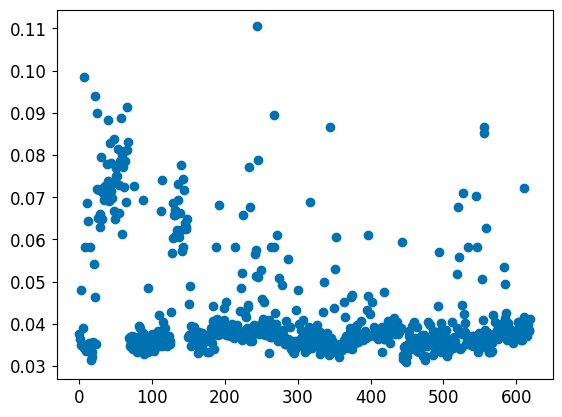

In [565]:
scores = []
for data in full_dataset:
    scores.append(anomaly_score(data.reshape(1, 1, 96)))
plt.scatter(range(len(scores)), scores)

In [566]:
[idx for idx, sc in enumerate(scores) if sc > 0.2]

[]

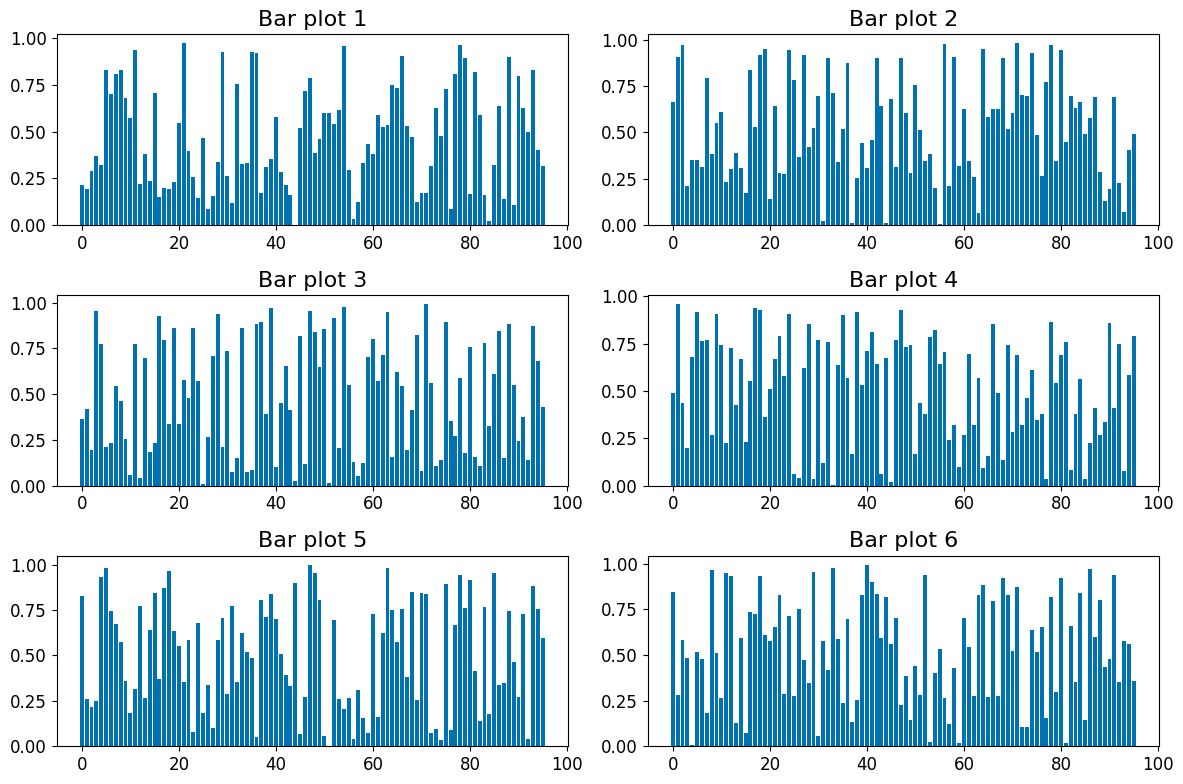

In [567]:
randoms = [torch.rand(96) for _ in range(6)]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (ax, data) in enumerate(zip(axes, randoms)):
    ax.bar(range(len(data)), data)
    ax.set_title(f"Bar plot {i+1}")

plt.tight_layout()
plt.show()

In [568]:
def mse_score(x):
    embed = encoder(x.reshape(1,1,96)).detach()
    pred = gen(embed)
    return nn.MSELoss()(x, pred)


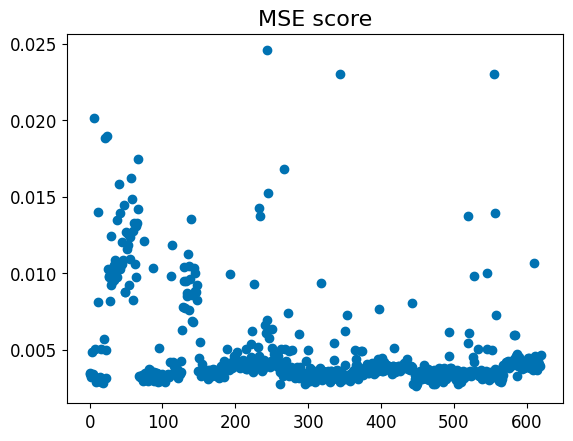

In [569]:
scores = []
for data in full_dataset:
    scores.append(mse_score(data.reshape(1, 1, 96)))
plt.scatter(range(len(scores)), scores)
plt.title("MSE score")
plt.show()

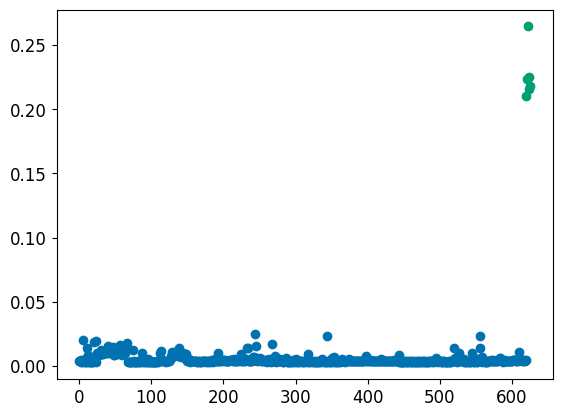

In [570]:
out_scores = []
for out in randoms:
    score = anomaly_score(out.reshape(1,1,96))
    out_scores.append(score)
plt.scatter(range(len(scores)), scores)
plt.scatter(range(len(scores), len(scores) + len(out_scores)), out_scores)
plt.show()

# Evaluation and results

In [571]:
preds = []

with torch.no_grad():
    for _, data in enumerate(full_dataset):
        pred = gen(encoder(data.reshape(1, 1, 96))).cpu().numpy().squeeze()
        
        for p in preds:
            if np.array_equal(pred, p):
                break
        else:
            preds.append(pred)

print(f"There are {len(preds)} unique representations that model outputs")

There are 613 unique representations that model outputs


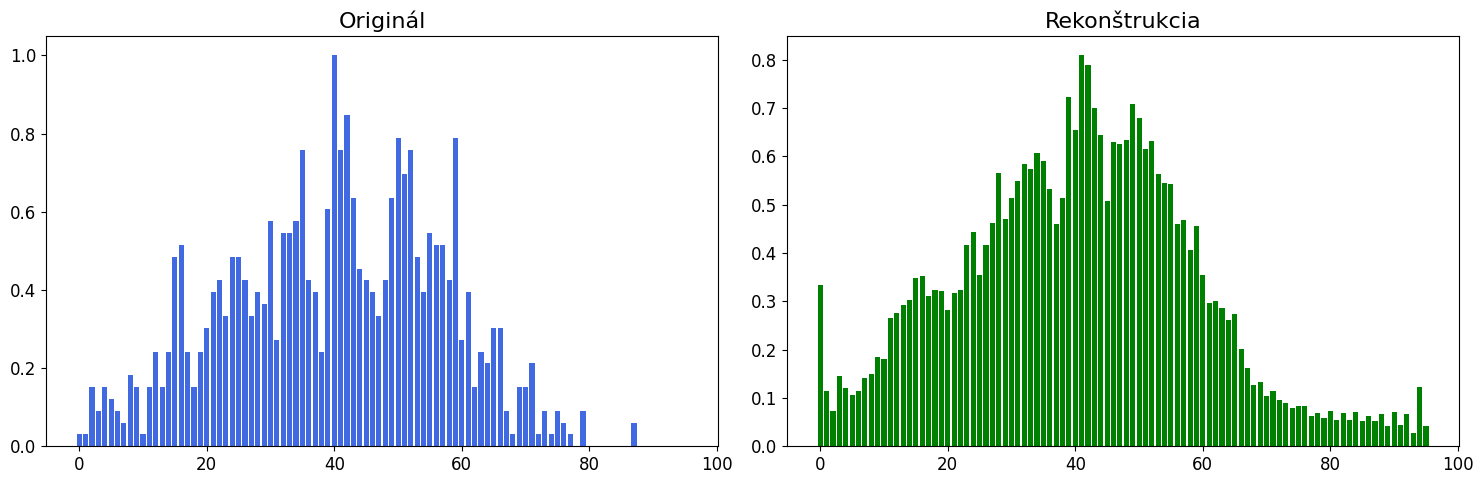

In [572]:
gen.eval()
encoder.eval()

orig_hist = full_dataset[65]
embed = encoder(orig_hist.reshape(1,1,96)).detach()

reconstruct = gen(embed.reshape(1,32,24)).detach().numpy().squeeze()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(range(len(orig_hist)), orig_hist, color='royalblue')
axes[0].set_title("Originál")

axes[1].bar(range(len(reconstruct)), reconstruct, color='green')
axes[1].set_title("Rekonštrukcia")

plt.tight_layout()
plt.show()

In [573]:
from anomaly_detection.config.paths import CHECKPOINT_DIR

SAVE = False

if SAVE:
    torch.save({
        "generator": gen.state_dict(),
        "discriminator": critic.state_dict(),
        "encoder": encoder.state_dict(),
    }, f"{CHECKPOINT_DIR}/f_anogan_v2/mode_ep{epoch}.pth")